<div style="text-align:center;">
    <img src="http://www.cs.wm.edu/~rml/images/wm_horizontal_single_line_full_color.png">
    <h1>CSCI 416-01/516-01 final exam</h1>
    <h1>Fall 2025</h1>
    <h1>Problem 1: Building a classifier for the 2016 presidential election</h1>
</div>

# Name: Aidan Basloe

# The task

The instructions may be found [here](#What-you-are-to-do).

In this problem you will look at county-level data for the 2016 presidential election.  The goal is to build a classifier to predict whether a county voted for Hillary Clinton or for Donald Trump.

The features for each county, [listed below](#The-features), are demographic and geographic information.

An interesting feature of the 2016 was the geographical narrowness of the areas that voted for Clinton, dubbed ["the Clinton archipelago"](https://vividmaps.com/trumpland-and-clinton-archipelago/).  Clinton carried relatively few, primarily urban, counties compared to Trump
<pre>
Class breakdown:  training set  test set  total
       Clinton       330          158       488
         Trump      1670          954      2624
</pre>
**Note that this is an imbalanced dataset so some of the techniques from Problem 0 on imbalanced learning might prove helpful.**

Observe that the simplest classifier we can build from the training data would be the majority classifier that predicts all counties vote Trump.  This classifier would be correct for  
$$
  1 - \frac{330}{330 + 1670} = 83.5\%
$$
of the training cases, and
$$
1 - \frac{158}{158 + 954} = 85.8\%
$$
of the test cases!  So whatever classifier you build must do substantially better than this.

**With only a few minutes experimentation, I found a classifier with greater than 98% accuracy overall, and at least 95% accuracy for each candidate.  Can you do better?  Aim for at least 94% accuracy for each candidate and at least 96% overall.**

# Prologue

In [1]:
%matplotlib inline
from IPython.display import Image
import matplotlib.pyplot as plt

In [2]:
# DO NOT CHANGE ANY OF THIS CODE CELL!

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sb

def compute_cm(clf, X, y, title=''):
  print(title)

  y_pred = clf.predict(X)

  print('Misclassified samples:', (y != y_pred).sum())
  print(f'Accuracy: {accuracy_score(y, y_pred):.3%}')

  cm = confusion_matrix(y, y_pred)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  print('Normalized confusion matrix')
  print(cm_normalized)

  return cm, cm_normalized, y_pred

def plot_cm(cm, class_names=[], title=''):
  if (class_names):
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
  else:
    df_cm = pd.DataFrame(cm)
  #plt.figure(figsize = (10,16))
  sb.heatmap(df_cm, annot=True)
  plt.title(title)

## Read the data

The columns whose name includes "fips" (for Federal Information Processing Standards) are unique identifiers that can be ignored.  The last columns are from an already fitted model and will also be ignored.

In [3]:
import pandas as pd
import numpy  as np

In [ ]:
df0 = pd.read_csv('vote16_data.csv') #had to change name for file name discrepency

# Look at the first few entries in the dataframe.
print(df0.head(10))

   combined_fips  votes_dem_2016  votes_gop_2016  total_votes_2016   Clinton  \
0           1001            5908           18110             24661  0.239569   
1           1003           18409           72780             94090  0.195653   
2           1005            4848            5431             10390  0.466603   
3           1007            1874            6733              8748  0.214220   
4           1009            2150           22808             25384  0.084699   
5           1011            3530            1139              4701  0.750904   
6           1013            3716            4891              8685  0.427864   
7           1015           13197           32803             47376  0.278559   
8           1017            5763            7803             13778  0.418276   
9           1019            1524            8809             10503  0.145101   

      Trump  diff_2016  per_point_diff_2016 state_abbr      county_name  ...  \
0  0.734358      12202            -0.49

## Permute the data.

The data appear by state, so we need to randomize it.

In [7]:
# Randomly permute the dataframe by sampling the entire frame.
df1 = df0.sample(frac=1.0, random_state=42)

## The features

The first few feature columns contain information about the 2012 election, including the proportion voting for Obama and Romney as well as the vote totals themselves.

Here are the details of the other county features:
<pre>
PST045214: Population, 2014 estimate
PST040210: Population, 2010 (April 1) estimates base
PST120214: Population, percent change - April 1, 2010 to July 1, 2014
POP010210: Population, 2010
AGE135214: Persons under 5 years, percent, 2014
AGE295214: Persons under 18 years, percent, 2014
AGE775214: Persons 65 years and over, percent, 2014
SEX255214: Female persons, percent, 2014
RHI125214: White alone, percent, 2014
RHI225214: Black or African American alone, percent, 2014
RHI325214: American Indian and Alaska Native alone, percent, 2014
RHI425214: Asian alone, percent, 2014
RHI525214: Native Hawaiian and Other Pacific Islander alone, percent, 2014
RHI625214: Two or More Races, percent, 2014
RHI725214: Hispanic or Latino, percent, 2014
RHI825214: White alone, not Hispanic or Latino, percent, 2014
POP715213: Living in same house 1 year & over, percent, 2009-2013
POP645213: Foreign born persons, percent, 2009-2013
POP815213: Language other than English spoken at home, pct age 5+, 2009-2013
EDU635213: High school graduate or higher, percent of persons age 25+, 2009-2013
EDU685213: Bachelor's degree or higher, percent of persons age 25+, 2009-2013
VET605213: Veterans, 2009-2013
LFE305213: Mean travel time to work (minutes), workers age 16+, 2009-2013
HSG010214: Housing units, 2014
HSG445213: Homeownership rate, 2009-2013
HSG096213: Housing units in multi-unit structures, percent, 2009-2013
HSG495213: Median value of owner-occupied housing units, 2009-2013
HSD410213: Households, 2009-2013
HSD310213: Persons per household, 2009-2013
INC910213: Per capita money income in past 12 months (2013 dollars), 2009-2013
INC110213: Median household income, 2009-2013
PVY020213: Persons below poverty level, percent, 2009-2013
BZA010213: Private nonfarm establishments, 2013
BZA110213: Private nonfarm employment,  2013
BZA115213: Private nonfarm employment, percent change, 2012-2013
NES010213: Nonemployer establishments, 2013
SBO001207: Total number of firms, 2007
SBO315207: Black-owned firms, percent, 2007
SBO115207: American Indian- and Alaska Native-owned firms, percent, 2007
SBO215207: Asian-owned firms, percent, 2007
SBO515207: Native Hawaiian- and Other Pacific Islander-owned firms, percent, 2007
SBO415207: Hispanic-owned firms, percent, 2007
SBO015207: Women-owned firms, percent, 2007
MAN450207: Manufacturers shipments, 2007 ($1,000)
WTN220207: Merchant wholesaler sales, 2007 ($1,000)
RTN130207: Retail sales, 2007 ($1,000)
RTN131207: Retail sales per capita, 2007
AFN120207: Accommodation and food services sales, 2007 ($1,000)
BPS030214: Building permits, 2014
LND110210: Land area in square miles, 2010
POP060210: Population per square mile, 2010
</pre>

In [8]:
y_cols = ['votes_dem_2016', 'votes_gop_2016']

x_cols = [
       'total_votes_2012', 'votes_dem_2012', 'votes_gop_2012', 
       'Obama', 'Romney', 'diff_2012', 'per_point_diff_2012',
       'population2014',
       'population2010', 'population_change', 'POP010210', 'AGE135214',
       'AGE295214', 'age65plus', 'SEX255214', 'White', 'Black', 'RHI325214',
       'RHI425214', 'RHI525214', 'RHI625214', 'Hispanic', 'RHI825214',
       'POP715213', 'POP645213', 'NonEnglish', 'Edu_highschool',
       'Edu_batchelors', 'VET605213', 'LFE305213', 'HSG010214', 'HSG445213',
       'HSG096213', 'HSG495213', 'HSD410213', 'HSD310213', 'Income',
       'INC110213', 'Poverty', 'BZA010213', 'BZA110213', 'BZA115213',
       'NES010213', 'SBO001207', 'SBO315207', 'SBO115207', 'SBO215207',
       'SBO515207', 'SBO415207', 'SBO015207', 'MAN450207', 'WTN220207',
       'RTN130207', 'RTN131207', 'AFN120207', 'BPS030214', 'LND110210'
]

In [9]:
X = np.float64(df1.loc[:,x_cols].to_numpy())
y = np.float64(df1.loc[:,y_cols].to_numpy())

X_train = X[:2000,:]
y_train = (y[:2000,1] > y[:2000,0])
X_test = X[2000:,:]
y_test = (y[2000:,1] > y[2000:,0])

class_names = ['Clinton', 'Trump']

test  = {}
train = {}
test['Clinton']  = (y_test == 0).sum()
train['Clinton'] = (y_train == 0).sum()
test['Trump']    = (y_test == 1).sum()
train['Trump']   = (y_train == 1).sum()

print('Class breakdown:  training set  test set  total')
print(f"       Clinton      {train['Clinton']:4d}         {test['Clinton']:4d}      {train['Clinton']+test['Clinton']:4d}")
print(f"       Trump        {train['Trump']:4d}         {test['Trump']:4d}      {train['Trump']+test['Trump']:4d}")

Class breakdown:  training set  test set  total
       Clinton       330          158       488
       Trump        1670          954      2624


# What you are to do

* No cheating!  do not use the test set to build the model!  😄
* Build a classifier that with 96% accuracy overall, and at least 94% accuracy for each candidate.
* You will need to name your classifier <code>clf</code> to be consistent with the rest of the code.
* You may choose any classifier you wish.  The following list is not meant to be exhaustive, so you feel free to express yourself in your choice of classifier, but possibilities include
  - [k nearest neighbors](http://scikit-learn.org/stable/modules/neighbors.html),
  - [support vector machines / kernel machines](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html),
  - [decision trees](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier),
  - [logistic regression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html),
  - [neural networks](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)
  - ensembles (i.e., [random forests](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and [AdaBoosted collections of weak learners](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)).
* Your classifier should be a scikit-learn <code>Pipeline</code> object that includes any preprocessing steps (e.g., scaling) that you perform.

# What you are to submit

* Submit a Jupyter notebook named <code>vote16_classification.ipynb</code> that shows your work and contains the code for the final model you decide on.
* Leave the code unchanged outside the section "Summary of what you tried" and "Your code".  I will be using the code outside these two sections in the grading.
* If you try a model and abandon it, you should include this code, but disable it in the code you submit, so the active code constructs only your final classifier.
* If you use a grid search or random search for hyperparameter tuning, you should include this code, but disable it in the code you submit, so the active code only constructs the final classifier.
* If you try a classifier and it does not work, just disable it but retain the code so I can see what you tried.
 
* You should begin with a summary of your work.  Questions to address include:
    -  What classifiers did you try, and how did they perform?
    -  If you chose an unsuccessful classifier, why do you think it was unsuccessful?
    -  Why did you choose the classifiers that you did to try?
    -  What hyperparameter tuning did you do, if any?
    -  Were there any surprises along the way?
    -  Can you interpret your model?  For instance, if you end up with a decision tree, explain what features figures in its decisions.  For other classifiers, try to give some insight into why they might work.

# Summary of what you tried

* Summarize your experiments here.

 
    -  What classifiers did you try, and how did they perform?  
        The first two I tried were pretty much just copy pasted versions of the ones from the part 0 of the project because those were introduced as working on unbalanced data sets. Honestly both of them worked pretty well so future iterations were just for tinkering and seeing if I could improve. Then I tried the randomforest because I was super confused by it in the part 0 so I thought I could try to use it here.
    -  If you chose an unsuccessful classifier, why do you think it was unsuccessful?  
        The only time any of the classifiers messed up was when I accidently put the max iterations for the SVC at 50 and it went down significantly. This is because the amount of layers
        decreased dramatically so the data was less refined and the model had less time to get the predictions accurate. 
    -  Why did you choose the classifiers that you did to try?  
        It was mostly just adapting the Part 0 ones because I thought they would all be easily applicable to this problem which turned out to be correct. 
    -  What hyperparameter tuning did you do, if any?  
        I didn't use any but if I did it would probably just been a group of penalty scores for logistic regression.
    -  Were there any surprises along the way?  
        My biggest suprise was honestly how well simply adapting the other classifiers to this one were. I kind of assumed that there would have to be a bunch of weird work arounds
        and edits I would have to make but it was all simple stuff that was straight forward. 
    -  Can you interpret your model?  For instance, if you end up with a decision tree, explain what features figures in its decisions.  For other classifiers, try to give some insight into why they might work.  
        For the final choice of RFC it is many decision trees (500) put together through bagging. This means that 500 trees are each done seperatrely where random subset of features are selected
        and compared looking at different thresholds to decided if it is one prediction or another. These seperatre trees have many different prediction outcomes and are sampled differently together that are then combined (ensemble learning) into a conglomerate prediction. 



# Your code

Your code goes in the following section.  You will likely need to add cells.

Training performance
Misclassified samples: 30
Accuracy: 98.500%
Normalized confusion matrix
[[1.    0.   ]
 [0.018 0.982]]


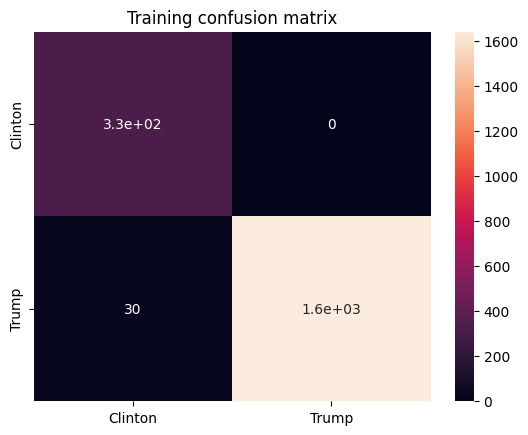

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

'''AttributeError("logreg", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=1000,
            random_state=42
        ))'''
        
'''('m', SVC(kernel='linear',max_iter=1000, random_state=42, class_weight='balanced', probability=True))'''
clf = Pipeline(
    steps=[
        # Scale features so LR behaves well
        ("t", StandardScaler()),

        # Linear (logistic) classifier
        ('m', RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_split=10, min_samples_leaf=5, class_weight="balanced", n_jobs =-1, random_state=42
                                     ))
        
        
    ]
)

            

# Train the classifier on the TRAINING set ONLY
clf.fit(X_train, y_train)

# Evaluate on training data (allowed; diagnostic only)
cm_train, cmn_train, y_pred_train = compute_cm(
    clf,
    X_train,
    y_train,
    title="Training performance"
)

plot_cm(cm_train, class_names=class_names, title="Training confusion matrix")


# Epilogue

Leave the following cells unchanged.  I will use them in testing your model.

In [23]:
# DO NOT CHANGE ANY OF THIS CODE CELL!

import seaborn as sb

np.set_printoptions(precision=3)

cm, cm_normalized, y_pred = compute_cm(clf, X_test, y_test)


Misclassified samples: 25
Accuracy: 97.752%
Normalized confusion matrix
[[0.981 0.019]
 [0.023 0.977]]


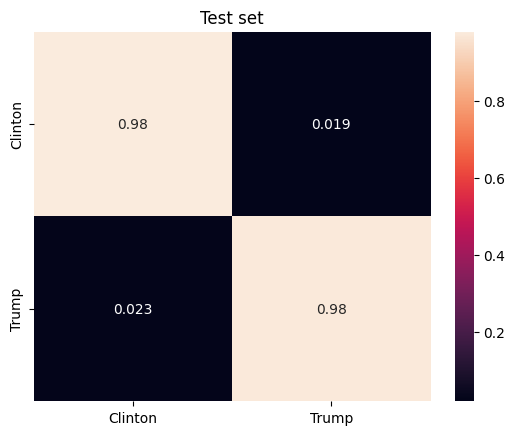

In [24]:
# DO NOT CHANGE ANY OF THIS CODE CELL!

plot_cm(cm_normalized, class_names, 'Test set')